In [1]:
import os
os.getcwd()
import sys
sys.path.append("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/run_models/scVI")
sys.path.append("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart")

In [2]:
import torch
import scvi
from model_config import *  # Imports all model configurations and parameters
import numpy as np

from scMEDAL.utils.utils import create_folder,read_adata,get_OHE,min_max_scaling,plot_rep,calculate_merge_scores,get_split_paths,calculate_zscores,get_clustering_scores_optimized
# from utils import create_folder,read_adata,get_OHE,min_max_scaling,plot_rep,calculate_merge_scores,get_split_paths,calculate_zscores,get_clustering_scores_optimized
from scMEDAL.utils.callbacks import ComputeLatentsCallback
import os
import tensorflow as tf
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, History
print("tf_version",tf.__version__)

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import glob
from anndata import AnnData
import scipy
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from scMEDAL.utils.utils import *
from scMEDAL.utils.model_train_utils import ModelManager, load_data#,compute_scores

/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


data_base_path: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../data/HealthyHeart_data
outputs_path: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../outputs/HealthyHeart_outputs


2025-05-02 14:28:23.848941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746214104.225381   43786 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746214104.318274   43786 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746214105.370492   43786 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746214105.370572   43786 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746214105.370580   43786 computation_placer.cc:177] computation placer alr

tf_version 2.19.0
Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../data/HealthyHeart_data/log_transformed_3000hvggenes/splits
Outputs saved to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../outputs/HealthyHeart_outputs
run_name: run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_batch_size-512_epochs-2_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_n_components-2_2025-05-02_14-28
save_model set to: True
tf_version 2.19.0


2025-05-02 14:28:52.379460: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
import os, gc, numpy as np, pandas as pd, scvi

def run_scvi_pipeline(
        Model,
        input_path_dict,
        build_model_dict,
        compile_dict,
        model_params,
        save_model,
        batch_col,
        bio_col,
        batch_col_categories=None,
        bio_col_categories=None,
        return_scores=False,
        return_adata_dict=False,
        return_trained_model=False,
        model_type="scvi",
        issparse=False,
        load_dense=True,
        shape_color_dict=None,
        sample_size=None,
        return_history=False,
):
    # ----------------- 1) LOAD DATA ----------------------
    adata_dict = load_data(
        input_path_dict,
        eval_test=model_params.eval_test,
        scaling=model_params.scaling,
        issparse=issparse,
        load_dense=load_dense
    )

    adata_train = adata_dict["train"]
    adata_val   = adata_dict["val"]
    adata_test  = adata_dict.get("test") if model_params.eval_test else None

    # ----------------- 2) SETUP + TRAIN -------------------
    scvi.model.SCVI.setup_anndata(adata_train, batch_key=batch_col)
    model = Model(
        adata_train,
        n_latent=build_model_dict.get("n_latent_dims", 10),
        n_layers=build_model_dict.get("n_layers", 2),
        gene_likelihood=build_model_dict.get("gene_likelihood", "zinb"),
        dispersion=build_model_dict.get("dispersion", "gene"),
    )
    model.train(
        max_epochs=model_params.epochs,
        batch_size=model_params.batch_size,
        early_stopping=True,
        check_val_every_n_epoch=10,
    )

    if save_model:
        model.save(model_params.model_path, overwrite=True)

    # ----------------- 3) HISTORY ------------------------
    history_raw = model.history
    try:
        # robust merge of dict of DataFrames or Series
        dfs = []
        for k, v in history_raw.items():
            if isinstance(v, pd.Series):
                dfs.append(v.to_frame(name=k))
            elif isinstance(v, pd.DataFrame):
                dfs.append(v.rename(columns={v.columns[0]: k}))
        history_df = pd.concat(dfs, axis=1)
        history_df.reset_index(inplace=True)
    except Exception:
        history_df = pd.DataFrame(history_raw)
    history_csv_path = os.path.join(model_params.latent_path, "history_scvi.csv")
    history_df.to_csv(history_csv_path, index=False)

    # ----------------- 4) LATENT + RECON -----------------
    def extract_and_store(ad, split_name):
        scvi.model.SCVI.setup_anndata(ad, batch_key=batch_col)
        latent = model.get_latent_representation(ad)
        ad.obsm["X_scvi"] = latent
        np.save(os.path.join(model_params.latent_path, f"z_{split_name}.npy"), latent)

        recon = model.get_normalized_expression(ad, return_numpy=True)
        np.save(os.path.join(model_params.latent_path, f"recon_{split_name}.npy"), recon)

    extract_and_store(adata_train, "train")
    extract_and_store(adata_val, "val")
    if adata_test is not None:
        extract_and_store(adata_test, "test")

    # ----------------- 5) CLUSTERING SCORES (optional) ----
    df_scores_dict = None
    if return_scores:
        df_scores_dict = {}
        for split, ad in adata_dict.items():
            z = ad.obsm["X_scvi"]
            idx = None
            if sample_size and sample_size < z.shape[0]:
                idx = np.random.choice(z.shape[0], sample_size, replace=False)
            z_eval = z if idx is None else z[idx]
            meta = ad.obs.iloc[idx] if idx is not None else ad.obs
            df_scores_dict[split] = compute_scores(
                z_eval,
                batch_labels=meta[batch_col],
                bio_labels=meta[bio_col] if bio_col else None,
            )

    gc.collect()

    # ----------------- 6) RETURN --------------------------
    results = {}
    if return_trained_model:
        results["model"] = model
    if return_scores:
        results["scores"] = df_scores_dict
    if return_adata_dict:
        results["adata"] = adata_dict
    if return_history:
        results["history"] = history_df

    return results


In [5]:
def run_model_pipeline(Model, input_path_dict, build_model_dict, compile_dict, model_params, save_model, batch_col, bio_col, batch_col_categories=None, bio_col_categories=None, return_scores=False, return_adata_dict=False, return_trained_model=False,model_type="ae_da",issparse=False, load_dense=True,shape_color_dict={"celltype_vs_donor": {"shape_col": "celltype", "color_col": "donor"}},sample_size=None,return_history=False):
    """
    Runs the full pipeline from loading data to training the model and processing latent representations. This is useful for AE,AEC,AE_DA,AE_RE,AE_conv
    Parameters:
    - Model: The model class to be instantiated and trained.
    - input_path_dict (dict): Dictionary containing paths to the training, validation, and optionally test datasets.
    - build_model_dict (dict): Dictionary of model building parameters.
    - compile_dict (dict): Dictionary of model compiling parameters.
    - model_params: Parameters and configurations for the model.
    - save_model (bool): Flag to determine whether to save the model.
    - batch_col (str): Name of the batch column in the dataset.
    - bio_col (str): Name of the biological column in the dataset.
    - batch_col_categories (list): List of categories for one-hot encoding of batch column.
    - bio_col_categories (list): List of categories for one-hot encoding of biological column.
    - return_scores (bool): Flag to return clustering scores.
    - return_adata_dict (bool): Flag to return the updated AnnData dictionary.
    - return_trained_model (bool): Flag to return the trained model.
    - model_type (str): For plotting loss. Options: ["ae_da","ae"]
    - issparse (bool): data is saved as sparse npy array
    - load_dense (bool): If True, forces conversion of sparse arrays to dense format.
    - shape_color_dict (dict, optional): Dictionary with shape_col and color_col combinations for plotting.
    - sample_size (int): sample size used to calculate clustering scores on a random subset of the latent space
    - return history (bool): Flag to return the history dataframe


    Returns:
    - dict: A dictionary of results, which may include the trained model, clustering scores, AnnData dictionary and history dataframe.
    """
    import gc
    print("input path dict",input_path_dict)
    # 1. Load data in dense format
    adata_dict = load_data(input_path_dict, eval_test=model_params.eval_test, scaling=model_params.scaling,issparse=issparse, load_dense=load_dense)
    print("loaded adata, adata_dict keys check:",adata_dict.keys())

    print("Batches available: ", np.unique(adata_dict["train"].obs[batch_col]))

    # 2. Prepare input and output data for training
    data_dict = get_train_val_data(adata_dict, batch_col=batch_col, bio_col=bio_col, get_pred=model_params.get_pred, use_z=model_params.use_z, batch_col_categories=batch_col_categories, bio_col_categories=bio_col_categories,eval_test=model_params.eval_test)
    train_in, train_out = data_dict['train_in'], data_dict['train_out']
    val_in, val_out = data_dict['val_in'], data_dict['val_out']
    if model_params.eval_test:
        test_in = data_dict['test_in']

    # Check the shape of 'train_in'
    # If 'train_in' is a tuple and has more than one element, print the shape of each element
    if isinstance(train_in, tuple) and len(train_in) > 1:
        print("train_in shapes (x, z):", train_in[0].shape, ",", train_in[1].shape)
    else:
        print("train_in shape x:", train_in.shape)

    # Check the shape of 'train_out'
    # If 'train_out' is a tuple and has more than one element, print the shape of each element
    if isinstance(train_out, tuple) and len(train_out) > 1:
        print("train_out shapes (x, y):", train_out[0].shape, ",", train_out[1].shape)
    else:
        print("train_out shape x:", train_out.shape)


    if model_type =="aec": #because AEC call method returns a dict not a tuple
        train_out_dict = {
        'reconstruction_output': train_out[0],
        'classification_output': train_out[1]}
        val_out_dict = {
            'reconstruction_output': val_out[0],
            'classification_output': val_out[1]}

    # Get metadata for callbacks
    metadata_dict = None
    if model_params.compute_latents_callback:
        metadata_dict={}
        metadata_dict["train"] = adata_dict["train"].obs 
        metadata_dict["val"] = adata_dict["val"].obs 


    # 3. Build and train model
    model = Model(in_shape=adata_dict["train"].shape, **build_model_dict)
    model.compile(**compile_dict)
    # Train the model with appropriate data format
    if model_type == "aec":
        trained_model, history = train_and_save_model(model, train_in, train_out_dict, val_in, val_out_dict, model_params, save_model,metadata_dict)
    else:
        trained_model, history = train_and_save_model(model, train_in, train_out, val_in, val_out, model_params, save_model,metadata_dict)
    print(trained_model.summary())
    # if model_type == "ae_re":
    #     print(trained_model.re_encoder.summary())
    #     print(trained_model.re_decoder.summary())
    if model_type == "ae_re":
        print("Available keys in re_layers:", trained_model.re_decoder.re_layers.keys())
        for key,layer in trained_model.re_decoder.re_layers.items():
            print(key," re layer summary\n",layer.summary())
    else:
        print(trained_model.encoder.summary())
        print(trained_model.decoder.summary())



    # 4. Plot Loss graph
    plot_params = {"outpath": model_params.plots_path}
    print("Starting plots")

    PlotLoss(history, model_params, save_model=save_model, model_type=model_type)

    # Ensure 'history' is in the correct format
    if isinstance(history, tf.keras.callbacks.History):
        history = history.history

    # Create a DataFrame from the history dictionary and save it to a CSV file
    history_df = pd.DataFrame(history)
    history_csv_path = os.path.join(model_params.latent_path, "history.csv")  # corrected path and added file extension
    
    history_df["epochs"]=history_df.index
    history_df.to_csv(history_csv_path)

    print(f"History saved to {history_csv_path}")

    # Before starting intensive computation or after completing a significant data processing step
    gc.collect()

   
    # Initialize z_ohe_dict
    z_ohe_dict = None

    # If model_type is 'ae_re', get z_ohe_dict

    # 6.1. Reconstruct input
    outputs = {
        "train": trained_model.predict(train_in, batch_size=model_params.batch_size),
        "val": trained_model.predict(val_in, batch_size=model_params.batch_size)
    }
    if model_params.eval_test:
        outputs["test"] = trained_model.predict(test_in, batch_size=model_params.batch_size)
    # ToDo: Here I need to add trained_model.predict(test_in) to outputs      

    # Check the model type and compute reconstructions accordingly
    for dataset_type in outputs:
        print("\nComputing reconstruction for ", dataset_type)
        output = outputs[dataset_type]

        if model_type == "ae":
            recon = output
        elif model_type == "aec":
            recon = output['reconstruction_output']
        elif model_type == "ae_da":
            if model_params.get_pred:
                recon, pred_class, pred_cluster = output
            else:
                recon, pred_cluster = output
        elif model_type == "ae_re":
            recon = output['recon']

        # Ensure recon is a numpy array
        if not isinstance(recon, np.ndarray):
            recon = np.array(recon)

        # Save recon outputs to a file at the specified latent path
        np.save(os.path.join(model_params.latent_path, "recon_" + dataset_type), recon)
        
        # Calculate and print standard deviations of the original and reconstructed data
        std_X = np.std(adata_dict[dataset_type].X, axis=1, ddof=1)  # Std of original data
        print(f"{dataset_type} std of X:", std_X)
        print(f"{dataset_type} Mean of std of X:", np.mean(std_X))
        
        std_recon = np.std(recon, axis=1, ddof=1)  # Std of reconstructed data
        print(f"{dataset_type} std of recon(X):", std_recon)
        print(f"Mean of std of recon(X):", np.mean(std_recon))



    gc.collect()

    # 7. Collect results based on flags
    results = {}
    if return_trained_model:
        results["model"] = trained_model
    if return_scores:
        results["scores"] = df_scores_dict
    if return_adata_dict:
        results["adata"] = adata_dict
    if return_history:
        results["history"]=history_df



    return results

In [6]:
# model = scvi.model.SCVI(adata)
# model.train()

In [7]:

print("TensorFlow version:", tf.__version__)
# Environment: run_models_env

# ---------------------------------------------------------------------------------------
# 0. Define 5-fold cross-validation
# ---------------------------------------------------------------------------------------
folds_list = list(range(1, 6, 1))  # [1, 2, 3, 4, 5]


# ---------------------------------------------------------------------------------------
# 1. Define batch and biological columns, and order of donors and cell types
# ---------------------------------------------------------------------------------------
# If you need a quick test, change model_params_dict["epochs"]. Note that this won't update
# the folder name for outputs, but can help you test faster.

batch_col = model_params_dict['batch_col']
bio_col = model_params_dict['bio_col']
donor_col = model_params_dict['donor_col']  # This column is optional

# For plotting latent spaces, different combinations of shape and color columns can be used.
# Basic combination is {"shape_col": bio_col, "color_col": bio_col}. When dealing with many
# cells, it might be hard to distinguish shapes, so consider only plotting one type of metadata.
shape_color_dict = {
    f"{bio_col}-{bio_col}": {"shape_col": bio_col, "color_col": bio_col},
    f"{donor_col}-{donor_col}": {"shape_col": donor_col, "color_col": donor_col},
    # Additional combinations could be uncommented if needed:
    # f"{bio_col}-{batch_col}": {"shape_col": bio_col, "color_col": batch_col},
    # f"{batch_col}-{batch_col}": {"shape_col": batch_col, "color_col": batch_col},
}


# ---------------------------------------------------------------------------------------
# 2. Load metadata to determine category ordering for donors and cell types
# ---------------------------------------------------------------------------------------
metadata_all = pd.read_csv(glob.glob(data_path + "/*meta.csv")[0])
metadata_all['celltype'] = metadata_all['celltype'].astype('category')
metadata_all['batch'] = metadata_all["sampleID"].astype('category')

num_batches = len(np.unique(metadata_all[batch_col]))
print("Number of batches:", num_batches)

# Get ordered donor IDs (seen batch categories)
seen_donor_ids = np.unique(metadata_all[batch_col]).tolist()
print("Ordered batches (seen donor IDs):", seen_donor_ids)

# Get ordered cell type IDs
celltype_ids = np.unique(metadata_all[bio_col]).tolist()


TensorFlow version: 2.19.0
Number of batches: 147
Ordered batches (seen donor IDs): ['H0015_LA_new', 'H0015_LV', 'H0015_RA', 'H0015_RV', 'H0015_apex', 'H0015_septum', 'H0020_LA_new', 'H0020_LV', 'H0020_RA', 'H0020_RV', 'H0020_apex', 'H0020_septum', 'H0025_LA', 'H0025_LV', 'H0025_RA', 'H0025_RV', 'H0025_apex', 'H0025_septum', 'H0026_LA', 'H0026_LV_V3', 'H0026_RA', 'H0026_RV', 'H0026_apex', 'H0026_septum2', 'H0035_LA', 'H0035_LV', 'H0035_RA', 'H0035_RV', 'H0035_apex', 'H0035_septum', 'H0037_Apex', 'H0037_LA_corr', 'H0037_LV', 'H0037_RA_corr', 'H0037_RV', 'H0037_septum', 'HCAHeart7606896', 'HCAHeart7656534', 'HCAHeart7656535', 'HCAHeart7656536', 'HCAHeart7656537', 'HCAHeart7656538', 'HCAHeart7656539', 'HCAHeart7664652', 'HCAHeart7664653', 'HCAHeart7664654', 'HCAHeart7698015', 'HCAHeart7698016', 'HCAHeart7698017', 'HCAHeart7702873', 'HCAHeart7702874', 'HCAHeart7702875', 'HCAHeart7702876', 'HCAHeart7702877', 'HCAHeart7702878', 'HCAHeart7702879', 'HCAHeart7702880', 'HCAHeart7702881', 'HCAHea

In [8]:

input_base_path=input_base_path
out_base_paths_dict=base_paths_dict
folds_list=folds_list  # For testing you can reduce the number of folds
run_name=run_name
# model_params_dict=model_params_dict
build_model_dict=build_model_dict
compile_dict=compile_dict
save_model=save_model
batch_col=batch_col
bio_col=bio_col
batch_col_categories=seen_donor_ids
bio_col_categories=celltype_ids
model_type="ae"
issparse=True
load_dense=True
shape_color_dict=shape_color_dict

In [9]:
# ---------------------------------------------------------------
# Cross-validation driver for scVI that matches your old signature
# ---------------------------------------------------------------

def run_scvi_across_folds(
        input_base_path: str,
        out_base_paths_dict: dict,
        folds_list: list[int],
        run_name: str,
        model_params_dict: dict,        # full parameter set
        build_model_dict: dict,
        compile_dict: dict,             # ignored, kept for compatibility
        save_model: bool,
        batch_col: str,
        bio_col: str,
        batch_col_categories=None,
        bio_col_categories=None,
        model_type: str = "scvi",       # kept, but has no effect on SCVI
        issparse: bool = True,
        load_dense: bool = True,
        shape_color_dict: dict | None = None,
        sample_size: int | None = None,
        return_scores_temp: bool = False,
):
    """
    Drop-in replacement for your old AE/AEC CV routine, now using scvi-tools.
    """

    import time, gc, numpy as np, pandas as pd, scvi

    # ------------------------------------------------------------------
    # Accumulators
    # ------------------------------------------------------------------
    all_scores, all_folds_adata, all_folds_model_params = {}, {}, {}
    all_history_df = pd.DataFrame()

    for intFold in folds_list:
        print(f"\n\nRunning Fold {intFold}\n\n")

        # 1 ?? update paths for this fold
        model_manager   = ModelManager(params_dict=model_params_dict,
                                       base_paths_dict=out_base_paths_dict,
                                       run_name=run_name,
                                       save_model=save_model,
                                       use_kfolds=True,
                                       kfold=intFold)
        model_params = model_manager.params

        # 2 ?? build dict with .h5ad paths (train/val/test)
        input_path_dict = get_split_paths(base_path=input_base_path, fold=intFold)
        print("input_path_dict ?", input_path_dict)

        # 3 ?? call the scvi pipeline
        fold_results = run_scvi_pipeline(
            Model                   = scvi.model.SCVI,
            input_path_dict         = input_path_dict,
            build_model_dict        = build_model_dict,
            compile_dict            = compile_dict,         # safely ignored
            model_params            = model_params,
            save_model              = save_model,
            batch_col               = batch_col,
            bio_col                 = bio_col,
            batch_col_categories    = batch_col_categories,
            bio_col_categories      = bio_col_categories,
            return_scores           = return_scores_temp,
            return_adata_dict       = True,
            return_trained_model    = False,
            model_type              = model_type,
            issparse                = issparse,
            load_dense              = load_dense,
            shape_color_dict        = shape_color_dict,
            sample_size             = sample_size,
            return_history          = True,
        )

        # --------------------------------------------------------------
        # 4 ?? store outputs
        # --------------------------------------------------------------
        all_folds_adata[intFold]        = fold_results["adata"]
        all_folds_model_params[intFold] = model_params

        if return_scores_temp:
            for split, df in fold_results["scores"].items():
                all_scores.setdefault(split, []).append(df)

        all_history_df = pd.concat([all_history_df,
                                    fold_results["history"].assign(fold=intFold)],
                                   ignore_index=True)

        gc.collect()

    # ------------------------------------------------------------------
    # 5 ?? Aggregate scores (optional)
    # ------------------------------------------------------------------
    if return_scores_temp:
        mean_scores = {split: pd.concat(dfs).groupby(level=0).mean()
                       for split, dfs in all_scores.items()}
    else:
        mean_scores = None

    return dict(
        mean_scores = mean_scores,
        all_adata   = all_folds_adata,
        all_params  = all_folds_model_params,
        history     = all_history_df,
    )


In [10]:
folds_list = [1]
cv_results = run_scvi_across_folds(
    input_base_path        = input_base_path,
    out_base_paths_dict    = base_paths_dict,
    folds_list             = folds_list,
    run_name               = run_name,
    model_params_dict      = model_params_dict,
    build_model_dict       = build_model_dict,
    compile_dict           = compile_dict,     # still pass it; it?s ignored
    save_model             = save_model,
    batch_col              = batch_col,
    bio_col                = bio_col,
    batch_col_categories   = seen_donor_ids,
    bio_col_categories     = celltype_ids,
    model_type             = "scvi",
    issparse               = True,
    load_dense             = True,
    shape_color_dict       = shape_color_dict,
    return_scores_temp     = False,            # or True if you want scores
)




Running Fold 1


Created folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../outputs/HealthyHeart_outputs/saved_models/log_transformed_3000hvggenes/scVI/run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_batch_size-512_epochs-2_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_n_components-2_2025-05-02_14-28/splits_1
Created folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../outputs/HealthyHeart_outputs/figures/log_transformed_3000hvggenes/scVI/run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_batch_size-512_epochs-2_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_n_components-2_2025-05-02_14-28/splits_1
Created folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../outputs/HealthyHeart_out

/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../data/HealthyHeart_data/log_transformed_3000hvggenes/splits/split_1/val
X.shape before scaling (97227, 3000)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/HealthyHeart/../data/HealthyHeart_data/log_transformed_3000hvggenes/splits/split_1/test
X.shape before scaling (97227, 3000)


...

/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 59 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 59 in adata.obs['_scvi_batch'] h

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 59 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/Aixa_scvi/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 59 in adata.obs['_scvi_batch'] h

In [ ]:

def postprocess_cv_results(cv_results, shape_color_dict, plot_params):
    """
    Postprocess cv_results to plot history and latent spaces.
    Always uses use_rep="X_scvi" inside plot_rep.
    """
    # 1. Plot training history
    history_df = cv_results["history"]
    plot_scvi_history(
        history_df,
        save_path=os.path.join(plot_params["outpath"], "scvi_history.png"),
        show=True
    )

    # 2. Plot latent spaces across folds and splits
    all_adata = cv_results["all_adata"]
    for fold, adata_splits in all_adata.items():
        print(f"\nPlotting latent space for fold {fold}")
        for split_name, adata in adata_splits.items():
            print(f"  Split: {split_name}")
            if shape_color_dict:
                for combo_name, combo_params in shape_color_dict.items():
                    shape_col = combo_params["shape_col"]
                    color_col = combo_params["color_col"]
                    file_name = f"{shape_col}-{color_col}_X_scvi_fold{fold}_{split_name}"
                    specific_plot_params = {**plot_params, "file_name": file_name}
                    plot_rep(
                        adata,
                        use_rep="X_scvi",  # <- hardcoded here
                        shape_col=shape_col,
                        color_col=color_col,
                        **specific_plot_params
                    )
    print("Finished all plots")






In [12]:
cv_results

{'mean_scores': None,
 'all_adata': {1: {'train': AnnData object with n_obs × n_vars = 291680 × 3000
       obs: 'Unnamed: 0.1', 'Unnamed: 0', 'Age', 'AgeBin', 'DeathType', 'DonorID', 'Gender', 'Organ', 'Race', 'SampleType', 'Source', 'Tissue', 'TissueDetail', '_index', 'celltype', 'protocol', 'sampleID', 'n_genes', 'batch', 'original_index', '_scvi_batch', '_scvi_labels'
       var: 'Unnamed: 0'
       uns: '_scvi_uuid', '_scvi_manager_uuid'
       obsm: 'X_scvi',
   'val': AnnData object with n_obs × n_vars = 97227 × 3000
       obs: 'Unnamed: 0.1', 'Unnamed: 0', 'Age', 'AgeBin', 'DeathType', 'DonorID', 'Gender', 'Organ', 'Race', 'SampleType', 'Source', 'Tissue', 'TissueDetail', '_index', 'celltype', 'protocol', 'sampleID', 'n_genes', 'batch', 'original_index', '_scvi_batch', '_scvi_labels'
       var: 'Unnamed: 0'
       uns: '_scvi_uuid', '_scvi_manager_uuid'
       obsm: 'X_scvi',
   'test': AnnData object with n_obs × n_vars = 97227 × 3000
       obs: 'Unnamed: 0.1', 'Unnamed: 0'

In [13]:
cv_results["all_adata"][1]["train"].obsm["X_scvi"]

array([[ 2.0060835,  2.799108 ],
       [-0.8589184, -4.3071146],
       [ 2.2078264,  2.063431 ],
       ...,
       [-4.904223 , -1.9212993],
       [-5.0858207, -2.8248725],
       [ 1.9597915,  2.950109 ]], dtype=float32)

In [40]:
def plot_rep(
    adata,
    shape_col="celltype",
    color_col="donor",
    use_rep="X_pca",
    markers=('o', 'v', '^', '<', '*'),
    clustering_scores=None,
    save_fig=True,
    outpath="",
    showplot=False,
    palette_choice="tab20",
    file_name="latent",
    figsize=(7, 7),
):
    """Plot 2‑D embedding with separate colour and shape legends, always visible."""
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from matplotlib.lines import Line2D

    print("Plotting latent representation:", use_rep)
    plt.ioff()
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    # ------------------------------------------------------------------
    # Unique categories
    # ------------------------------------------------------------------
    unique_shapes = np.unique(adata.obs[shape_col])
    unique_colors = np.unique(adata.obs[color_col])

    # ------------------------------------------------------------------
    # Colour palette
    # ------------------------------------------------------------------
    if isinstance(palette_choice, list):
        color_palette = palette_choice
    elif palette_choice == "hsv":
        color_palette = sns.color_palette("hsv", len(unique_colors))
    elif palette_choice == "tab20":
        color_palette = [plt.cm.tab20(i) for i in np.linspace(0, 1, len(unique_colors))]
    elif palette_choice == "Set2":
        color_palette = sns.color_palette("Set2", len(unique_colors))
    else:
        raise ValueError("palette_choice must be 'hsv', 'tab20', 'Set2', or a list of colours")

    color_map = {c: color_palette[i] for i, c in enumerate(unique_colors)}
    shape_map = {s: markers[i % len(markers)] for i, s in enumerate(unique_shapes)}

    # ------------------------------------------------------------------
    # Coordinates
    # ------------------------------------------------------------------
    coords = adata.X if use_rep == "X" else adata.obsm[use_rep]
    x, y = coords[:, 0], coords[:, 1]

    for s in unique_shapes:
        for c in unique_colors:
            mask = (adata.obs[shape_col] == s) & (adata.obs[color_col] == c)
            ax.scatter(x[mask], y[mask],
                       color=color_map[c],
                       marker=shape_map[s],
                       alpha=0.7,
                       s=1)

    # ------------------------------------------------------------------
    # Legends
    # ------------------------------------------------------------------
    # Colour legend (coloured circles)
    colour_handles = [Line2D([0], [0], marker='o', linestyle='',
                             markerfacecolor=color_map[c], markeredgecolor='none',
                             markersize=10)
                      for c in unique_colors]
    legend_colour = ax.legend(
        handles=colour_handles,
        labels=list(unique_colors),
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        title=color_col,
    )
    ax.figure.add_artist(legend_colour)

    # Shape legend (black outlines with shape markers)
    shape_handles = [Line2D([0], [0], marker=shape_map[s], linestyle='',
                            color='black', markerfacecolor='none',
                            markersize=10, markeredgewidth=1.5)
                     for s in unique_shapes]
    legend_shape = ax.legend(
        handles=shape_handles,
        labels=list(unique_shapes),
        loc='lower center',
        bbox_to_anchor=(0.5, -0.65),
        ncol=3,
        title=shape_col,
    )

    extra_artists = (legend_colour, legend_shape)

    # ------------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------------
    if "pca" in use_rep and "variance_ratio" in adata.uns.get("pca", {}):
        vr = adata.uns['pca']["variance_ratio"]
        ax.set_xlabel(f"PC 1 ({vr[0]*100:.2f} %)")
        ax.set_ylabel(f"PC 2 ({vr[1]*100:.2f} %)")
    else:
        ax.set_xlabel(f"{use_rep} 1")
        ax.set_ylabel(f"{use_rep} 2")

    # ------------------------------------------------------------------
    # Save / show
    # ------------------------------------------------------------------
    if save_fig and outpath:
        fig.savefig(f"{outpath}/{use_rep}_{file_name}.png",
                    bbox_extra_artists=extra_artists,
                    bbox_inches="tight")
    if showplot:
        plt.show()
    else:
        plt.close(fig)



Plotting latent representation: X_scvi


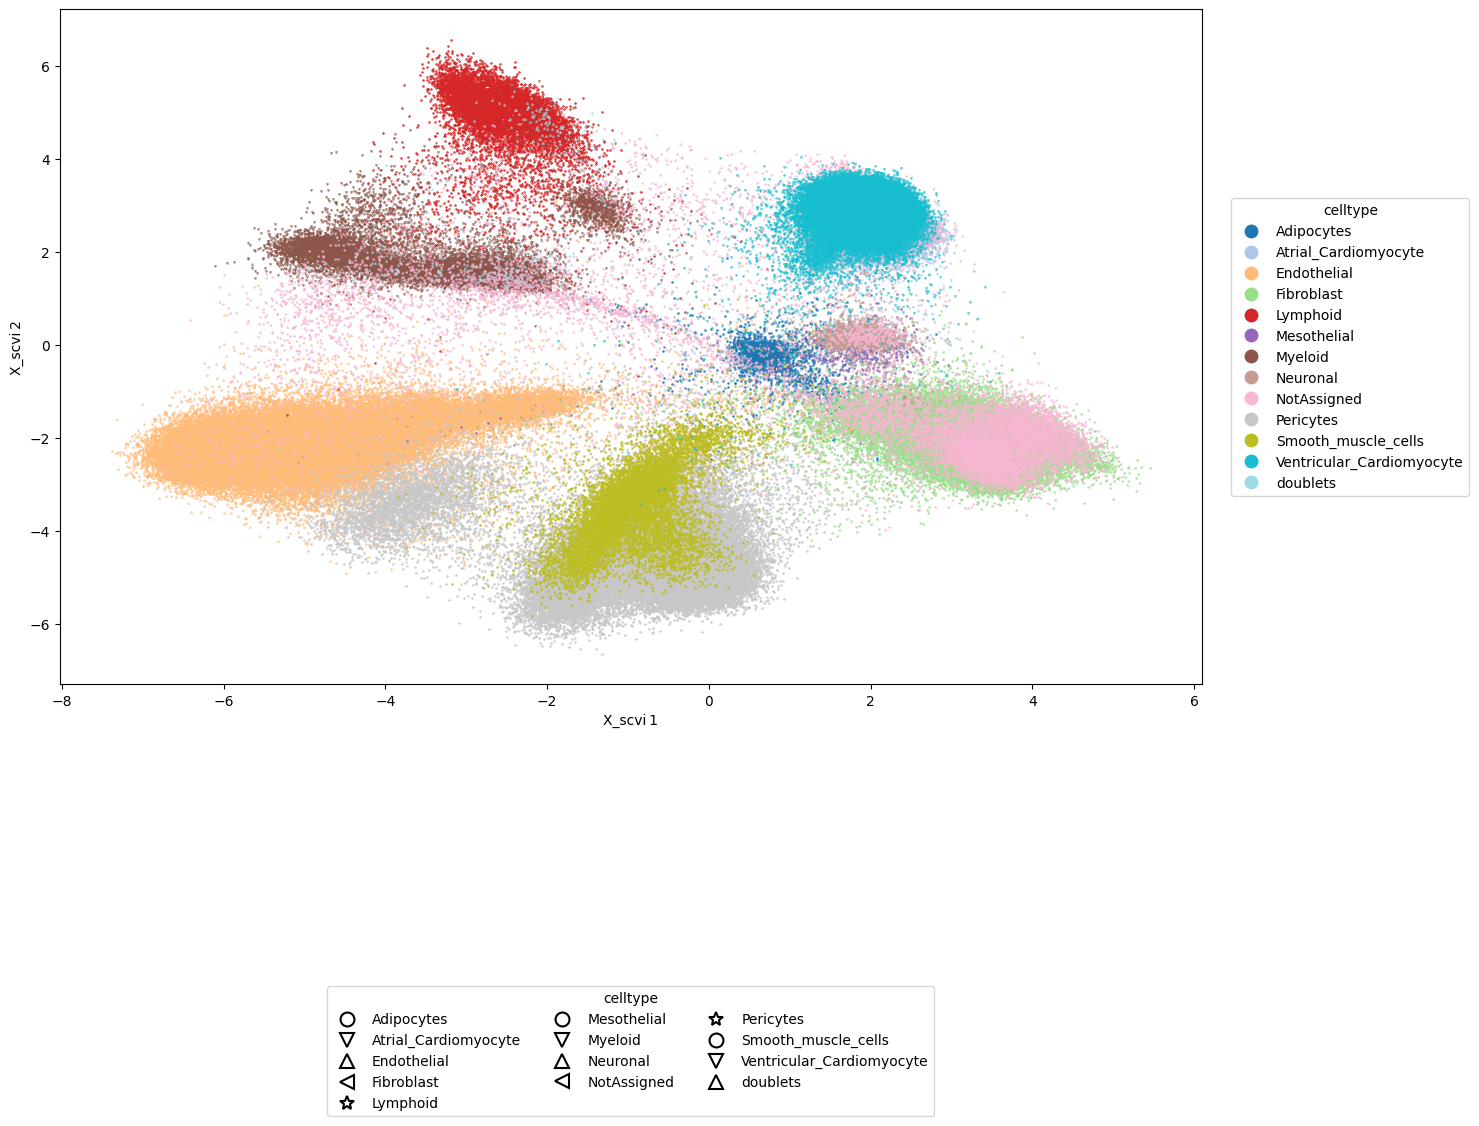

In [41]:
plot_rep(
    adata=adata,
    use_rep="X_scvi",
    shape_col="celltype",
    color_col="celltype",   # same column → only colour legend displayed
    markers=['o', 'v', '^', '<', '*'],
    save_fig=True,
    outpath="",
    showplot=True,
    palette_choice="tab20",
    file_name="train_scvi_latent",
    figsize=(12, 10)
)

In [21]:
shape_color_dict

{'celltype-celltype': {'shape_col': 'celltype', 'color_col': 'celltype'},
 'DonorID-DonorID': {'shape_col': 'DonorID', 'color_col': 'DonorID'}}

In [22]:
import matplotlib.pyplot as plt

def plot_scvi_history(history_df, save_path=None, show=True):
    """
    Plots losses and metrics from scVI training history.
    
    Parameters:
    - history_df (pd.DataFrame): history DataFrame with columns like
      'epoch', 'train_loss_step', 'validation_loss', 'elbo_validation',
      'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation'.
    - save_path (str or None): if given, saves the figure to this file.
    - show (bool): whether to display the plot.
    """
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    ax = ax.flatten()

    # --- Plot train + validation total loss ---
    if 'train_loss_step' in history_df and 'validation_loss' in history_df:
        ax[0].plot(history_df['epoch'], history_df['train_loss_step'], label='Train Loss')
        ax[0].plot(history_df['epoch'], history_df['validation_loss'], label='Validation Loss')
        ax[0].set_title('Total Loss')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Loss')
        ax[0].legend()

    # --- Plot reconstruction loss ---
    if 'reconstruction_loss_validation' in history_df:
        ax[1].plot(history_df['epoch'], history_df['reconstruction_loss_validation'], label='Reconstruction Loss (Val)')
        ax[1].set_title('Reconstruction Loss (Validation)')
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Loss')
        ax[1].legend()

    # --- Plot KL local ---
    if 'kl_local_validation' in history_df:
        ax[2].plot(history_df['epoch'], history_df['kl_local_validation'], label='KL Local (Val)')
        ax[2].set_title('KL Local (Validation)')
        ax[2].set_xlabel('Epoch')
        ax[2].set_ylabel('KL')
        ax[2].legend()

    # --- Plot KL global ---
    if 'kl_global_validation' in history_df:
        ax[3].plot(history_df['epoch'], history_df['kl_global_validation'], label='KL Global (Val)')
        ax[3].set_title('KL Global (Validation)')
        ax[3].set_xlabel('Epoch')
        ax[3].set_ylabel('KL')
        ax[3].legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"Saved history plot to: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()


Saved history plot to: scvi_history.png


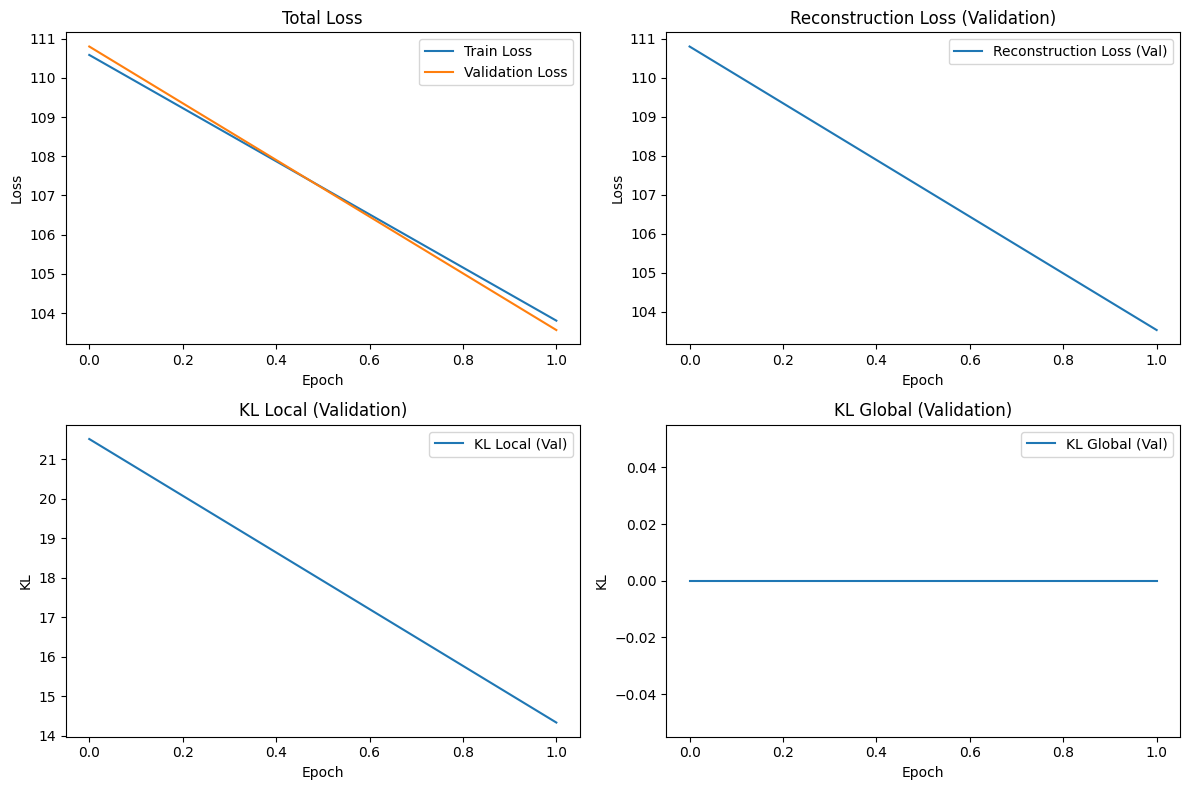


Plotting latent space for fold 1
  Split: train
plotting latent representation: X_scvi
unique_colorcol ['Adipocytes' 'Atrial_Cardiomyocyte' 'Endothelial' 'Fibroblast' 'Lymphoid'
 'Mesothelial' 'Myeloid' 'Neuronal' 'NotAssigned' 'Pericytes'
 'Smooth_muscle_cells' 'Ventricular_Cardiomyocyte' 'doublets']
plotting latent representation: X_scvi
unique_colorcol ['D1' 'D11' 'D2' 'D3' 'D4' 'D5' 'D6' 'D7' 'H2' 'H3' 'H4' 'H5' 'H6' 'H7']
  Split: val
plotting latent representation: X_scvi
unique_colorcol ['Adipocytes' 'Atrial_Cardiomyocyte' 'Endothelial' 'Fibroblast' 'Lymphoid'
 'Mesothelial' 'Myeloid' 'Neuronal' 'NotAssigned' 'Pericytes'
 'Smooth_muscle_cells' 'Ventricular_Cardiomyocyte' 'doublets']
plotting latent representation: X_scvi
unique_colorcol ['D1' 'D11' 'D2' 'D3' 'D4' 'D5' 'D6' 'D7' 'H2' 'H3' 'H4' 'H5' 'H6' 'H7']
  Split: test
plotting latent representation: X_scvi
unique_colorcol ['Adipocytes' 'Atrial_Cardiomyocyte' 'Endothelial' 'Fibroblast' 'Lymphoid'
 'Mesothelial' 'Myeloid' 'Ne

In [24]:
postprocess_cv_results(
    cv_results=cv_results,
    shape_color_dict=shape_color_dict,
    plot_params={
        "markers": ['o', 'v', '^', '<', '*'],
        "save_fig": True,
        "outpath": "",
        "showplot": False,
        "palette_choice": "tab20"
    }
)

Saved history plot to: scvi_history.png


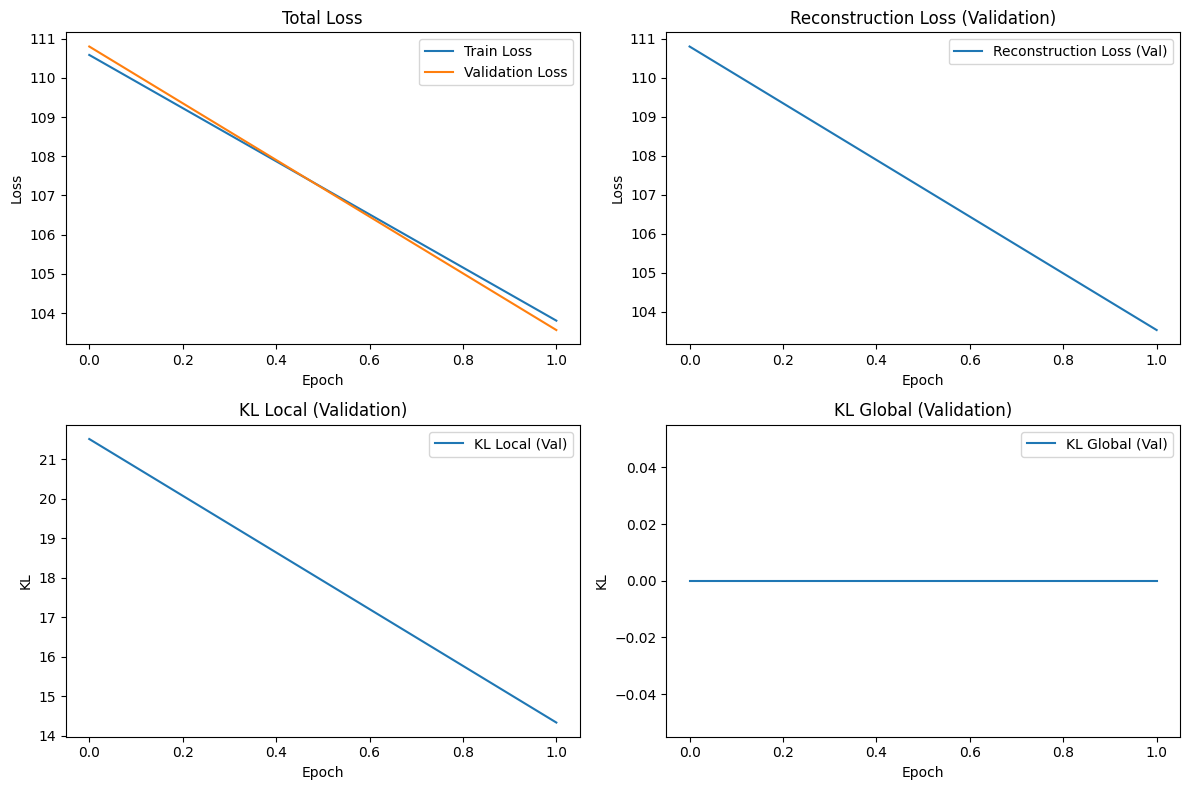

In [46]:
history_df = cv_results["history"]
plot_params={
        "markers": ['o', 'v', '^', '<', '*'],
        "save_fig": True,
        "outpath": "",
        "showplot": False,
        "palette_choice": "tab20"
    }
plot_scvi_history(
    history_df,
    save_path=os.path.join(plot_params["outpath"], "scvi_history.png"),
    show=True)

In [45]:
plot_params["outpath"]